In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches_df = pd.read_csv('/content/matches.csv')
deliveries_df = pd.read_csv('/content/deliveries.csv')

print("Matches DataFrame loaded:")
display(matches_df.head())

print("\nDeliveries DataFrame loaded:")
display(deliveries_df.head())

Matches DataFrame loaded:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan



Deliveries DataFrame loaded:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:

players_in_match = pd.concat([
    deliveries_df[['match_id', 'batter']].rename(columns={'batter': 'player'}),
    deliveries_df[['match_id', 'non_striker']].rename(columns={'non_striker': 'player'}),
    deliveries_df[['match_id', 'bowler']].rename(columns={'bowler': 'player'})
]).drop_duplicates().reset_index(drop=True)

matches_played_per_player = players_in_match.groupby('player')['match_id'].nunique().reset_index()
matches_played_per_player.rename(columns={'match_id': 'total_matches_played'}, inplace=True)

print("Total matches played per player:")
display(matches_played_per_player.head())

Total matches played per player:


,player,total_matches_played
0,A Ashish Reddy,28
1,A Badoni,35
2,A Chandila,12
3,A Chopra,6
4,A Choudhary,5


In [9]:
potm_awards = matches_df.groupby('player_of_match').size().reset_index(name='potm_awards')
potm_awards.rename(columns={'player_of_match': 'player'}, inplace=True)

player_stats = pd.merge(matches_played_per_player, potm_awards, on='player', how='left')
player_stats['potm_awards'] = player_stats['potm_awards'].fillna(0)
player_stats['potm_awards'] = player_stats['potm_awards'].astype(int)

player_stats['regular_potm_ratio'] = player_stats['potm_awards'] / player_stats['total_matches_played']


playoff_finals_df = matches_df[matches_df['match_type'].isin(['Qualifier', 'Eliminator', 'Semi-Final', 'Final', 'Playoff'])]


playoff_finals_potm = playoff_finals_df.groupby('player_of_match').size().reset_index(name='playoff_finals_potm_awards')
playoff_finals_potm.rename(columns={'player_of_match': 'player'}, inplace=True)


player_stats = pd.merge(player_stats, playoff_finals_potm, on='player', how='left')
player_stats['playoff_finals_potm_awards'] = player_stats['playoff_finals_potm_awards'].fillna(0)
player_stats['playoff_finals_potm_awards'] = player_stats['playoff_finals_potm_awards'].astype(int)


playoff_deliveries_df = deliveries_df[deliveries_df['match_id'].isin(playoff_finals_df['id'])]

players_in_playoff_finals = pd.concat([
    playoff_deliveries_df[['match_id', 'batter']].rename(columns={'batter': 'player'}),
    playoff_deliveries_df[['match_id', 'non_striker']].rename(columns={'non_striker': 'player'}),
    playoff_deliveries_df[['match_id', 'bowler']].rename(columns={'bowler': 'player'})
]).drop_duplicates()

player_playoff_matches = players_in_playoff_finals.groupby('player')['match_id'].nunique().reset_index()
player_playoff_matches.rename(columns={'match_id': 'total_playoff_finals_matches'}, inplace=True)

player_stats = pd.merge(player_stats, player_playoff_matches, on='player', how='left')
player_stats['total_playoff_finals_matches'] = player_stats['total_playoff_finals_matches'].fillna(0)
player_stats['total_playoff_finals_matches'] = player_stats['total_playoff_finals_matches'].astype(int)


player_stats['playoff_finals_potm_ratio'] = player_stats['playoff_finals_potm_awards'] / player_stats['total_playoff_finals_matches']
player_stats['playoff_finals_potm_ratio'] = player_stats['playoff_finals_potm_ratio'].fillna(0)

player_stats_filtered = player_stats[player_stats['total_matches_played'] >= 20]

print("Player statistics with PotM ratios:")
display(player_stats_filtered.sort_values(by='regular_potm_ratio', ascending=False).head())

Player statistics with PotM ratios:


,player,total_matches_played,potm_awards,regular_potm_ratio,playoff_finals_potm_awards,total_playoff_finals_matches,playoff_finals_potm_ratio
379,MEK Hussey,58,12,0.206897,0,5,0.0
181,DP Conway,22,4,0.181818,1,1,1.0
515,RD Gaikwad,65,11,0.169231,0,2,0.0
132,CH Gayle,141,22,0.156028,0,3,0.0
32,AB de Villiers,170,25,0.147059,1,5,0.2


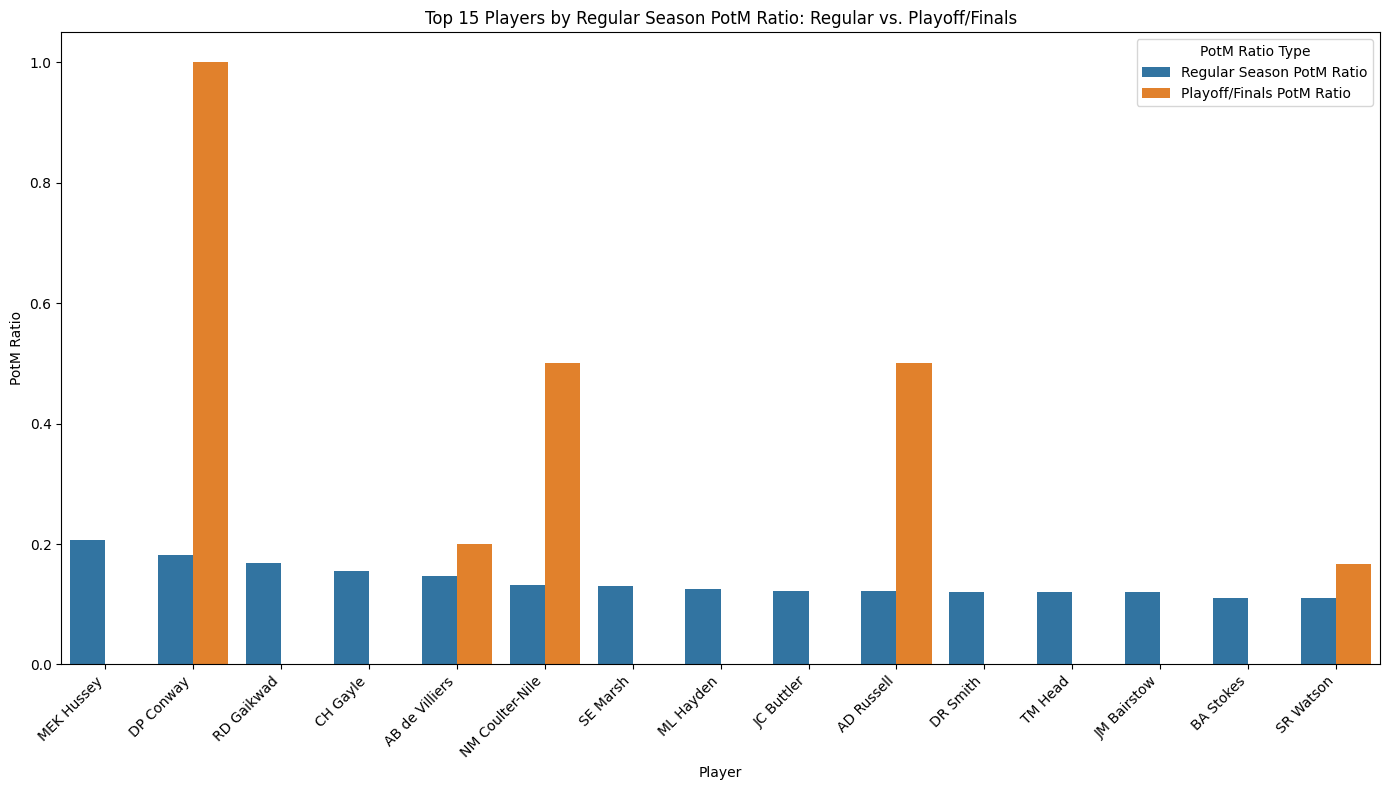

In [10]:
top_15_players = player_stats_filtered.sort_values(by='regular_potm_ratio', ascending=False).head(15)


plot_df = top_15_players[['player', 'regular_potm_ratio', 'playoff_finals_potm_ratio']]
plot_df_melted = plot_df.melt(id_vars='player', var_name='ratio_type', value_name='ratio_value')

plot_df_melted['ratio_type'] = plot_df_melted['ratio_type'].map({
    'regular_potm_ratio': 'Regular Season PotM Ratio',
    'playoff_finals_potm_ratio': 'Playoff/Finals PotM Ratio'
})

plt.figure(figsize=(14, 8))
sns.barplot(x='player', y='ratio_value', hue='ratio_type', data=plot_df_melted)
plt.xlabel('Player')
plt.ylabel('PotM Ratio')
plt.title('Top 15 Players by Regular Season PotM Ratio: Regular vs. Playoff/Finals')
plt.xticks(rotation=45, ha='right')
plt.legend(title='PotM Ratio Type')
plt.tight_layout()
plt.show()